# Catfish Water Quality Prediction Model
This notebook loads water quality data, preprocesses it, trains a machine learning model, and predicts water quality status for catfish farming.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Set plot style
sns.set(style="whitegrid")

## Problem Definition & ML Strategy

### The Problem
The dataset (`WQD.xlsx`) contains various chemical and biological water quality measurements, such as temperature, dissolved oxygen (DO), pH, and turbidity. The final column, "Water Quality," is our target variable.

Based on the snippets, the "Water Quality" column contains discrete integer values (e.g., 0, 2), indicating this is a **classification problem**. The goal is to build a model that can predict the water quality class based on the other measurements.

### How ML Can Help
A machine learning classification model can learn the complex, non-linear relationships between the different measurements and the resulting water quality.

* **Prediction:** Once trained, the model can instantly classify new water samples, providing a real-time monitoring tool.
* **Insight:** The model can help identify which factors (e.g., 'BOD', 'Turbidity') are the most important predictors of poor water quality.
* **Automation:** This automates a potentially slow and complex manual assessment process, allowing for faster responses to pollution events.

In [2]:
# Load the dataset
file_name = 'WQD.xlsx'
df = pd.read_excel(file_name)

# --- Data Cleaning (from snippet inspection) ---
# The 'pH`' column in the snippet has a trailing backtick. Let's fix it.
if 'pH`' in df.columns:
    df = df.rename(columns={'pH`': 'pH'})


In [3]:
# Display first few rows and data types
print(df.head())
print("\n" + "="*50 + "\n")
print(df.info())
print(df.describe())

        Temp  Turbidity (cm)   DO(mg/L)  BOD (mg/L)        CO2         pH  \
0  67.448725       10.127148   0.208153    7.473607  10.181084   4.751657   
1  64.626666       94.015595  11.434463   10.859998  14.860521   3.085154   
2  65.121842       90.653462  12.430865   12.809970  12.319980   9.648515   
3   1.640334        0.066344  10.963529    8.508023  12.955209   4.819988   
4  64.863434        2.119173   1.361736   13.335372  13.603197  10.244034   

   Alkalinity (mg L-1 )  Hardness (mg L-1 )  Calcium (mg L-1 )  \
0            218.364855          300.125080         337.178226   
1            273.939692            8.426776         363.660740   
2            220.812730           11.726274         309.370934   
3            266.571628            6.627655           8.180468   
4            252.108000          339.891514         253.996871   

   Ammonia (mg L-1 )  Nitrite (mg L-1 )  Phosphorus (mg L-1 )  H2S (mg L-1 )  \
0           0.286054           4.355310              0.00598

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())



Missing values per column:
Temp                    0
Turbidity (cm)          0
DO(mg/L)                0
BOD (mg/L)              0
CO2                     0
pH                      0
Alkalinity (mg L-1 )    0
Hardness (mg L-1 )      0
Calcium (mg L-1 )       0
Ammonia (mg L-1 )       0
Nitrite (mg L-1 )       0
Phosphorus (mg L-1 )    0
H2S (mg L-1 )           0
Plankton (No. L-1)      0
Water Quality           0
dtype: int64


In [5]:
# Simple imputation: fill missing values with the median of the column
# (Median is more robust to outliers than mean)
for col in df.columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled NaNs in '{col}' with median: {median_val}")


In [6]:
# Define Features (X) and Target (y)
target = 'Water Quality'
X = df.drop(target, axis=1)
y = df[target]

## Exploratory Data Analysis (EDA))

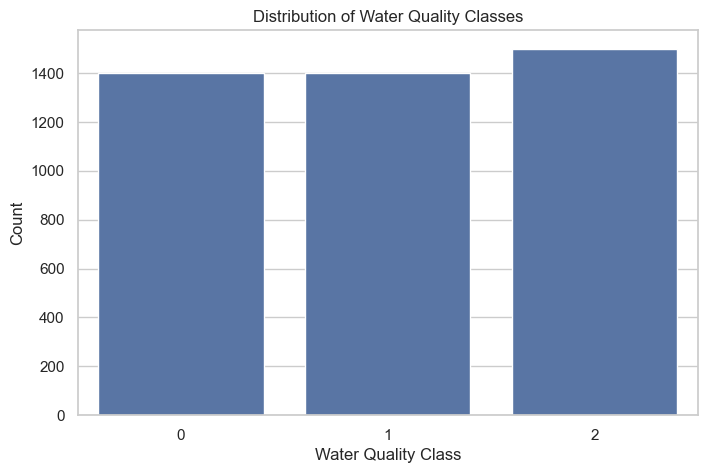

In [7]:
# 1. Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title('Distribution of Water Quality Classes')
plt.xlabel('Water Quality Class')
plt.ylabel('Count')
plt.show()



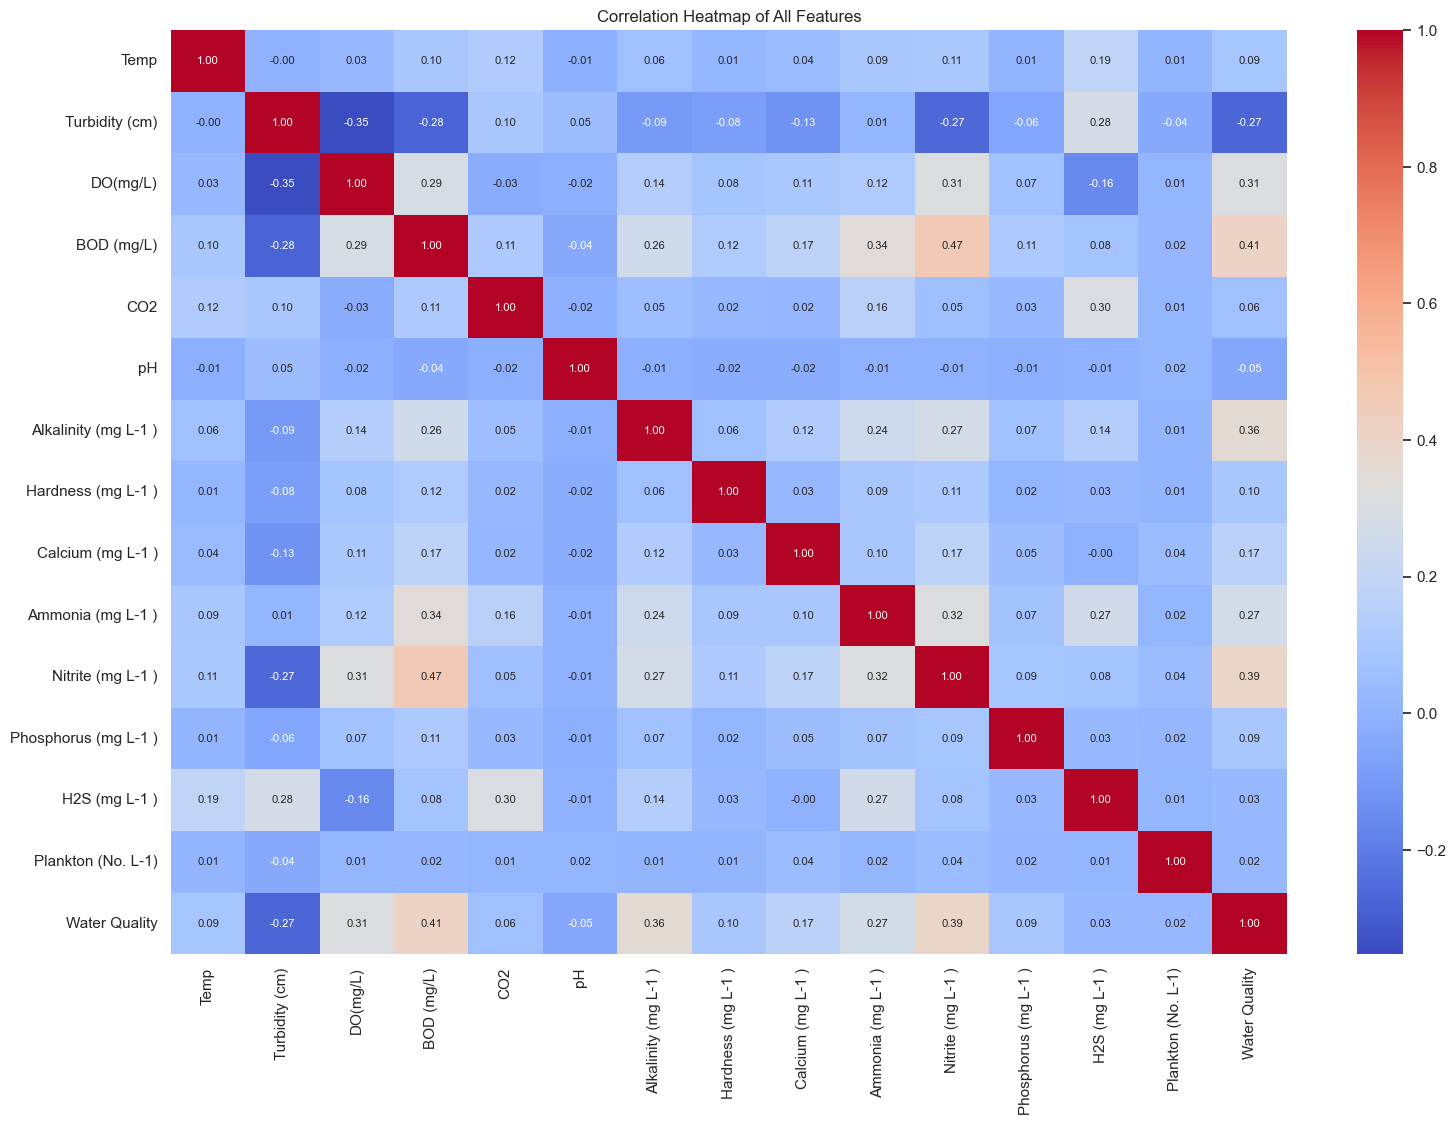

In [8]:
# 2. Correlation Heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', annot_kws={"size": 8})
plt.title('Correlation Heatmap of All Features')
plt.show()



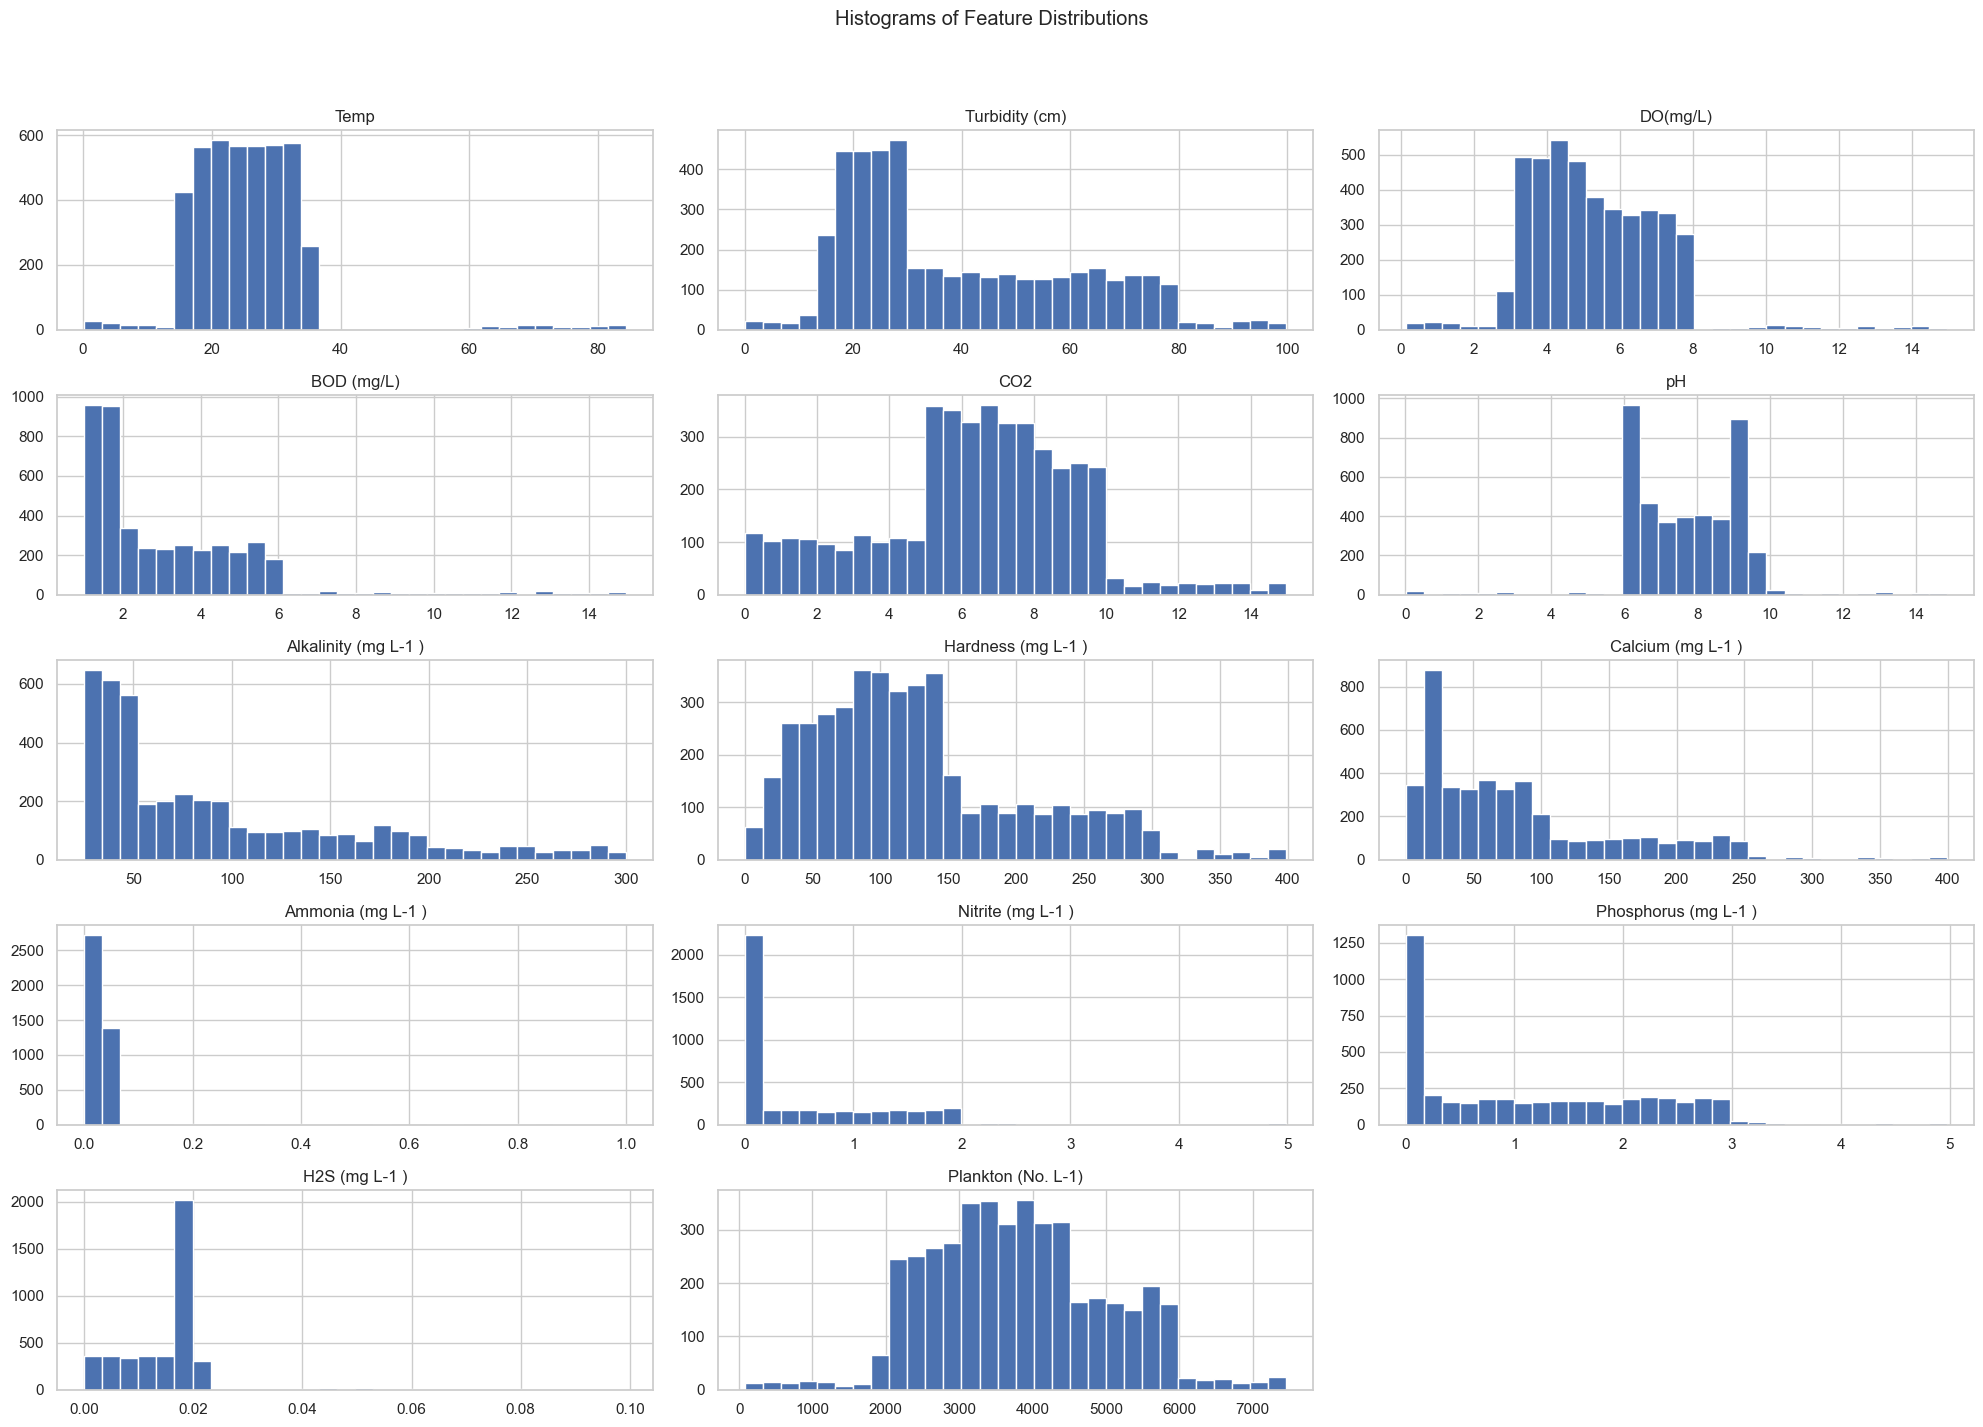

In [9]:
# 3. Feature Distributions
X.hist(bins=30, figsize=(20, 15), layout=(5, 3))
plt.suptitle('Histograms of Feature Distributions')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Preprocessing and Splitting

In [10]:
# Split data into training and testing sets
# We use stratify=y to ensure the class distribution is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
# ML models (especially linear ones) perform better when features are on a similar scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# We will try three common, powerful classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}



In [12]:
# Iterate, train, and evaluate
for name, model in models.items():
    print(f"--- Training {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    print("\n")

# Random Forest and Gradient Boosting usually perform best out-of-the-box.
# Let's pick Random Forest to tune.

--- Training Logistic Regression ---
Accuracy: 0.8140
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       280
           1       0.78      0.86      0.82       280
           2       0.82      0.60      0.69       300

    accuracy                           0.81       860
   macro avg       0.81      0.82      0.81       860
weighted avg       0.81      0.81      0.81       860



--- Training Random Forest ---
Accuracy: 0.9930
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       280
           1       0.99      1.00      0.99       280
           2       1.00      0.98      0.99       300

    accuracy                           0.99       860
   macro avg       0.99      0.99      0.99       860
weighted avg       0.99      0.99      0.99       860



--- Training Gradient Boosting ---
Accuracy: 0.9860
              precision    recall  f1-score   support

           0       0.99  

## Hyperparameter Tuning

In [13]:
# Define a smaller, faster parameter grid for demonstration
# You can expand this for a more exhaustive search
param_grid = {
    'n_estimators': [100, 200],      # Number of trees
    'max_depth': [10, 20, None],     # Max depth of trees
    'min_samples_split': [2, 5],     # Min samples to split a node
    'min_samples_leaf': [1, 2]       # Min samples at a leaf node
}

In [14]:
# Use GridSearchCV to find the best parameters
# cv=3 for 3-fold cross-validation (faster)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,  # Use all available CPU cores
    scoring='accuracy',
    verbose=1
)

In [15]:
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters found: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


## Model Evaluation

In [16]:
# Evaluate the tuned model on the test set
y_pred_final = best_model.predict(X_test_scaled)


print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(classification_report(y_test, y_pred_final))


Accuracy: 0.9930
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       280
           1       0.99      1.00      0.99       280
           2       1.00      0.98      0.99       300

    accuracy                           0.99       860
   macro avg       0.99      0.99      0.99       860
weighted avg       0.99      0.99      0.99       860



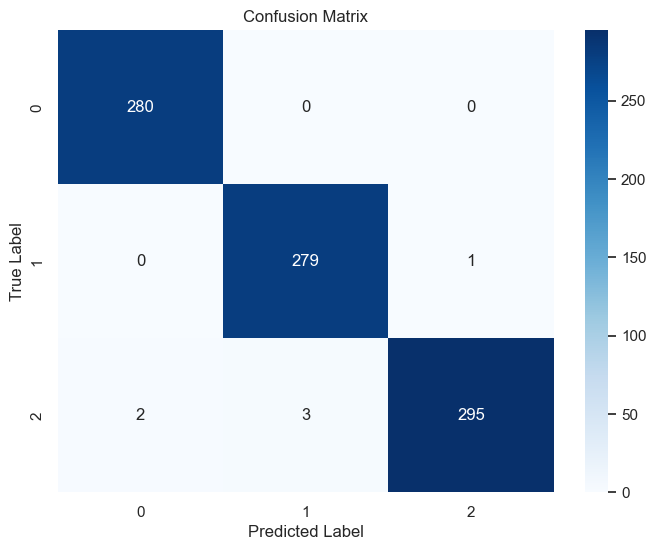

In [17]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()